**Capítulo 9**  


In [1]:
!pip install gower


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pyclustering


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Bibliotecas e funções necessárias
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    pairwise_distances
)

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import scipy.spatial.distance as ssd
from scipy.spatial.distance import squareform

import gower

from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.cluster.encoder import type_encoding
from pyclustering.utils.metric import distance_metric, type_metric

In [7]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak", category=UserWarning)

In [9]:
# Aplicação 1
# Importando a base de dados

un = pd.read_excel("UNMODIFIED.xlsx")
un_numeric = un.select_dtypes(include='number').copy()  # arquivo apenas com quantitativas
un_numeric = un_numeric.drop(columns=['id', 'ppgdp'])

print(un_numeric.columns.tolist())
print(un_numeric.corr().round(2))

['fertility', 'lifeExpF', 'pctUrban', 'infantMortality', 'logppgdp']
                 fertility  lifeExpF  pctUrban  infantMortality  logppgdp
fertility             1.00     -0.81     -0.53             0.85     -0.72
lifeExpF             -0.81      1.00      0.58            -0.93      0.77
pctUrban             -0.53      0.58      1.00            -0.59      0.73
infantMortality       0.85     -0.93     -0.59             1.00     -0.79
logppgdp             -0.72      0.77      0.73            -0.79      1.00


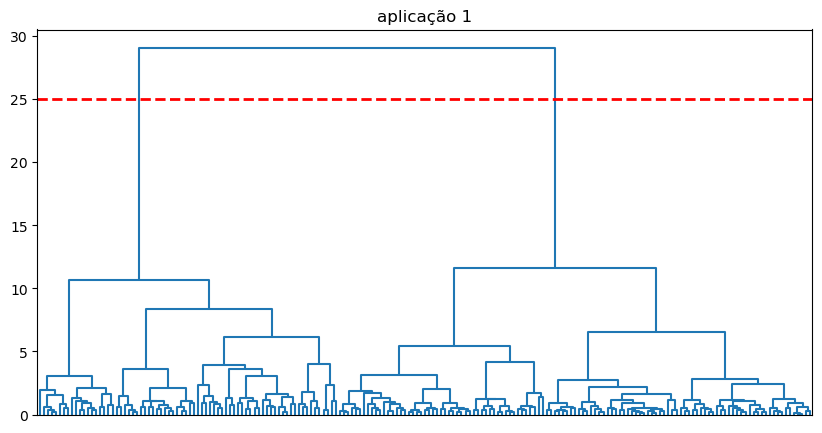

In [11]:
# Removendo a variável 'infantMortality':
un_numeric = un_numeric.drop(columns=['infantMortality'])

# Padronizando os dados:
scaler = StandardScaler()
un_num_padr = scaler.fit_transform(un_numeric)  

# Matriz de distâncias euclidianas
dist_matrix = ssd.pdist(un_num_padr, metric='euclidean')

# Cluster hierárquico (Ward)
hc1 = linkage(dist_matrix, method='ward')

# Plot do dendrograma
plt.figure(figsize=(10, 5))
dendrogram(hc1, no_labels=True, color_threshold=0) 
plt.title("aplicação 1")

plt.axhline(y=25, color='red', linestyle='--', linewidth=2)

plt.show()

In [13]:
# Definir número de clusters (k = 2)
labels = fcluster(hc1, t=2, criterion='maxclust')

# Anexar ao DataFrame original
un["hc1"] = labels

# Obter a contagem por cluster
print(un["hc1"].value_counts())

hc1
2    117
1     74
Name: count, dtype: int64


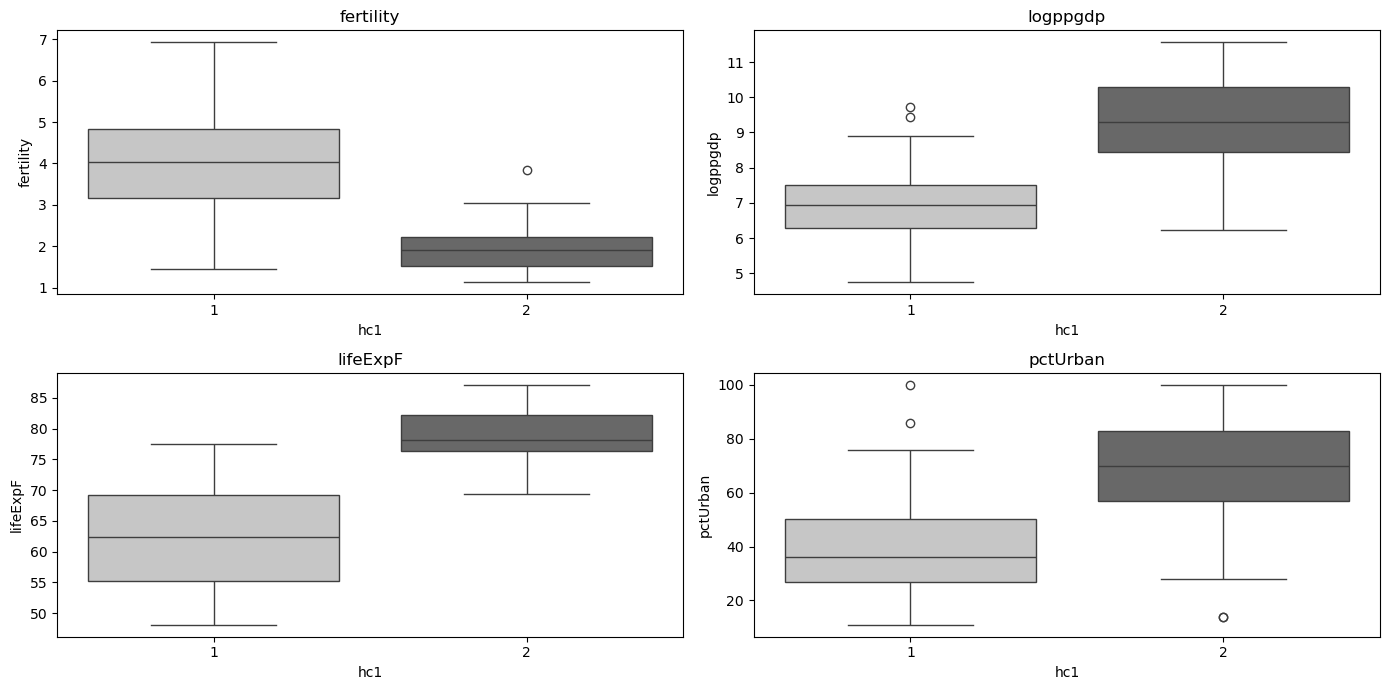

In [15]:
# Gráficos
vars_to_plot = ["fertility", "logppgdp", "lifeExpF", "pctUrban"]

fig, axs = plt.subplots(2, 2, figsize=(14, 7))

for ax, var in zip(axs.flatten(), vars_to_plot):
    sns.boxplot(data=un, x="hc1", y=var, palette="Greys", ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [17]:
# Tabelas de frequências
tab = pd.crosstab(un["region"], un["hc1"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

tab = pd.crosstab(un["group"], un["hc1"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

Frequências:
hc1             1   2
region               
Africa         44   7
Asia           16  33
Caribbean       1  12
Europe          1  38
Latin Amer      2  18
North America   0   2
Oceania        10   7

Proporções por linha:
hc1                   1         2
region                           
Africa         0.862745  0.137255
Asia           0.326531  0.673469
Caribbean      0.076923  0.923077
Europe         0.025641  0.974359
Latin Amer     0.100000  0.900000
North America  0.000000  1.000000
Oceania        0.588235  0.411765
Frequências:
hc1      1   2
group         
africa  44   7
oecd     0  31
other   30  79

Proporções por linha:
hc1            1         2
group                     
africa  0.862745  0.137255
oecd    0.000000  1.000000
other   0.275229  0.724771


In [19]:
# Aplicação 2
cols = ["region", "group", "fertility", "lifeExpF", "pctUrban", "logppgdp"]

un_mix = un[cols].copy()
un_mix["region"] = un_mix["region"].astype("category")
un_mix["group"]  = un_mix["group"].astype("category")

for c in ["fertility", "lifeExpF", "pctUrban", "logppgdp"]:
    un_mix[c] = pd.to_numeric(un_mix[c], errors="coerce")

print(un_mix.dtypes)

region       category
group        category
fertility     float64
lifeExpF      float64
pctUrban        int64
logppgdp      float64
dtype: object


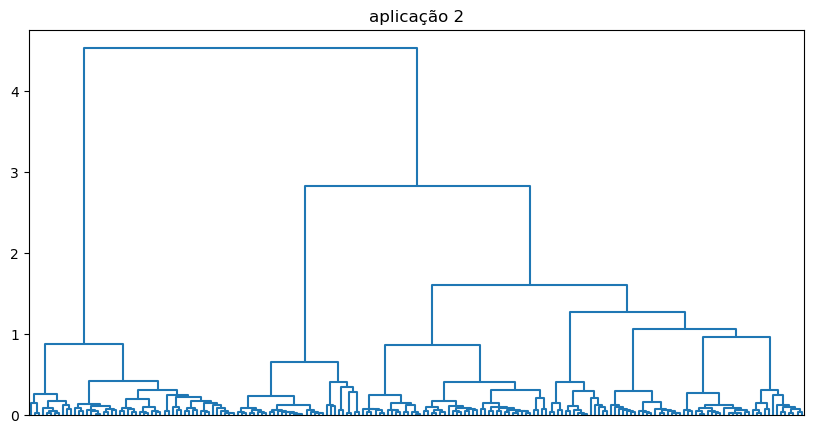

In [21]:
# Matriz de distâncias Gower
un_mix_convertida = un_mix.copy()

for col in un_mix_convertida.select_dtypes(include=['category']).columns:
    un_mix_convertida[col] = un_mix_convertida[col].astype(str)

un_mix_dist = gower.gower_matrix(un_mix_convertida)
dist_condensada = squareform(un_mix_dist, checks=False)

hc2 = linkage(dist_condensada, method='ward')

# Plotagem
plt.figure(figsize=(10, 5))
dendrogram(hc2, no_labels=True, color_threshold=0)
plt.title("aplicação 2")
plt.show()

hc2
3    109
1     51
2     31
Name: count, dtype: int64


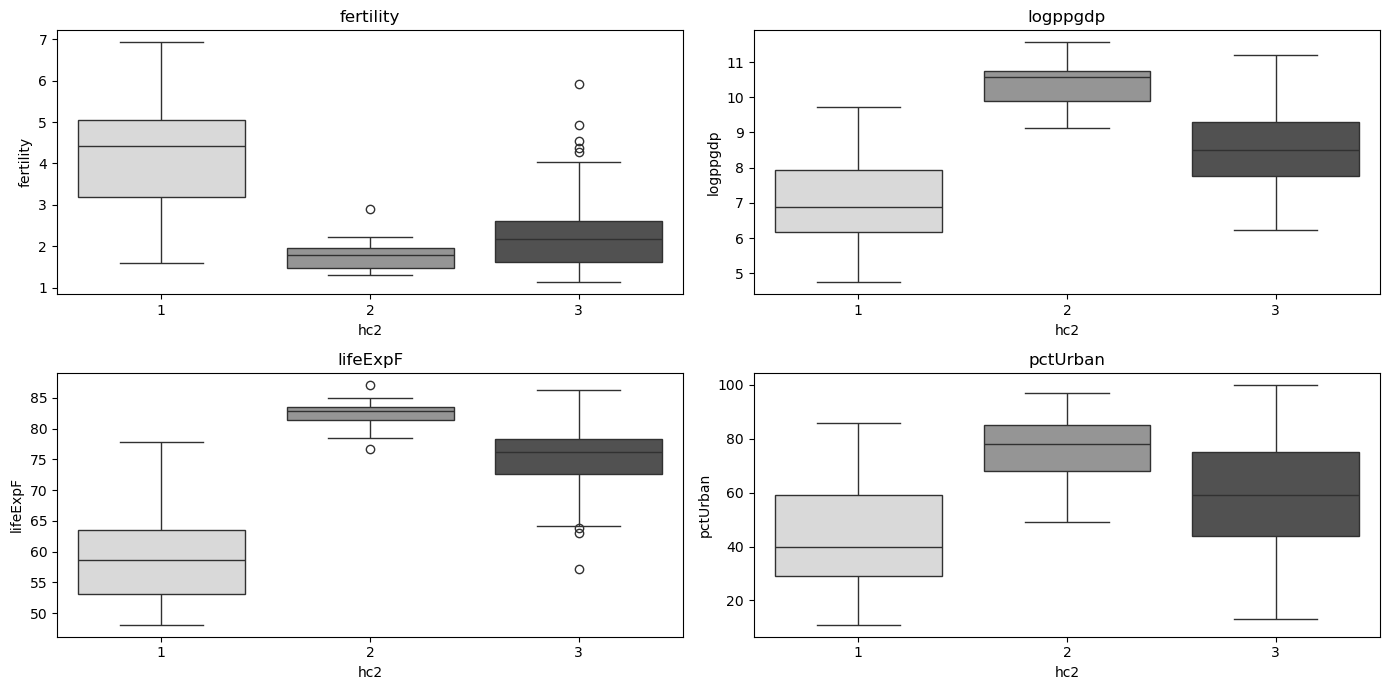

In [23]:
# Definir número de clusters 
labels2 = fcluster(hc2, t=3, criterion='maxclust')

# Anexar ao DataFrame original
un["hc2"] = labels2

print(un["hc2"].value_counts())

# Gráficos
vars_to_plot = ["fertility", "logppgdp", "lifeExpF", "pctUrban"]

fig, axs = plt.subplots(2, 2, figsize=(14, 7))

for ax, var in zip(axs.flatten(), vars_to_plot):
    sns.boxplot(data=un, x="hc2", y=var, palette="Greys", ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [25]:
# Tabelas de frequências
tab = pd.crosstab(un["region"], un["hc2"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

tab = pd.crosstab(un["group"], un["hc2"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

Frequências:
hc2             1   2   3
region                   
Africa         51   0   0
Asia            0   3  46
Caribbean       0   0  13
Europe          0  22  17
Latin Amer      0   2  18
North America   0   2   0
Oceania         0   2  15

Proporções por linha:
hc2              1         2         3
region                                
Africa         1.0  0.000000  0.000000
Asia           0.0  0.061224  0.938776
Caribbean      0.0  0.000000  1.000000
Europe         0.0  0.564103  0.435897
Latin Amer     0.0  0.100000  0.900000
North America  0.0  1.000000  0.000000
Oceania        0.0  0.117647  0.882353
Frequências:
hc2      1   2    3
group              
africa  51   0    0
oecd     0  31    0
other    0   0  109

Proporções por linha:
hc2       1    2    3
group                
africa  1.0  0.0  0.0
oecd    0.0  1.0  0.0
other   0.0  0.0  1.0


In [27]:
# Aplicação 3

# Escolhendo o número ótimo de clusters por diferentes critérios
def avaliar_clusters(X, min_k=2, max_k=8):
    resultados = []
    for k in range(min_k, max_k+1):
        kmeans = KMeans(n_clusters=k, random_state=123)
        labels = kmeans.fit_predict(X)

        sil = silhouette_score(X, labels)
        calinski = calinski_harabasz_score(X, labels)
        davies = davies_bouldin_score(X, labels)

        resultados.append({
            'k': k,
            'silhouette': sil,
            'calinski_harabasz': calinski,
            'davies_bouldin': davies
        })
    return resultados

resultados = avaliar_clusters(un_num_padr, min_k=2, max_k=8)

df_res = pd.DataFrame(resultados)
print(df_res)

   k  silhouette  calinski_harabasz  davies_bouldin
0  2    0.478922         248.152974        0.814353
1  3    0.378077         218.765488        0.945797
2  4    0.316744         187.912840        1.101830
3  5    0.279183         161.025141        1.169860
4  6    0.289411         157.276770        1.150546
5  7    0.283946         145.544960        1.088366
6  8    0.273629         138.137771        1.187816


In [29]:
# Agrupando com k = 2 clusters:
X = un_num_padr

kmeans = KMeans(n_clusters=2, n_init=25, random_state=18)
labels = kmeans.fit_predict(X)

# WSS total
wss_total = kmeans.inertia_
print("WSS total:", wss_total)

# Tamanho de cada cluster
sizes = np.bincount(labels, minlength=2)
print("Tamanhos dos clusters:", sizes)

# Adicionar os rótulos ao DataFrame original
un["kmn"] = labels + 1  # (+1 se quiser clusters numerados como 1,2, lembrando que o indexador em Python inicia em 0)

WSS total: 330.31000269232277
Tamanhos dos clusters: [ 74 117]


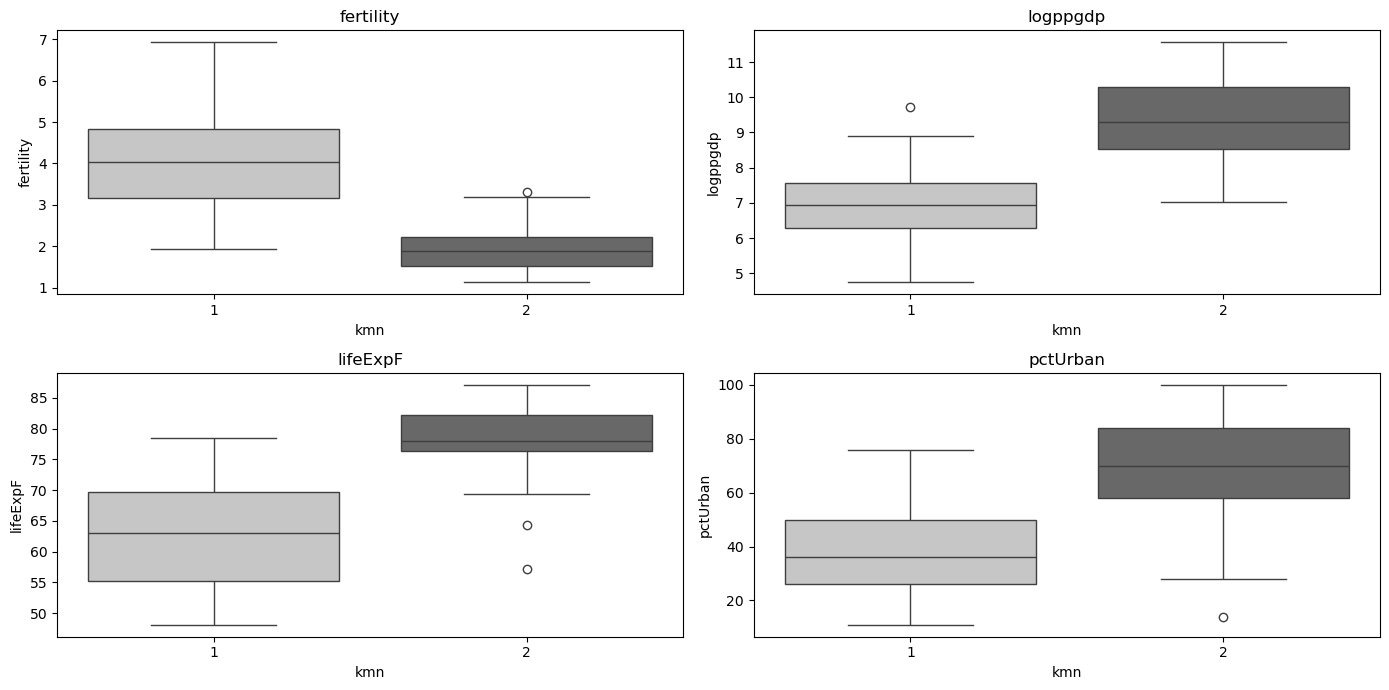

Frequências:
kmn             1   2
region               
Africa         43   8
Asia           18  31
Caribbean       1  12
Europe          0  39
Latin Amer      3  17
North America   0   2
Oceania         9   8

Proporções por linha:
kmn                   1         2
region                           
Africa         0.843137  0.156863
Asia           0.367347  0.632653
Caribbean      0.076923  0.923077
Europe         0.000000  1.000000
Latin Amer     0.150000  0.850000
North America  0.000000  1.000000
Oceania        0.529412  0.470588
Frequências:
kmn      1   2
group         
africa  43   8
oecd     0  31
other   31  78

Proporções por linha:
kmn            1         2
group                     
africa  0.843137  0.156863
oecd    0.000000  1.000000
other   0.284404  0.715596


In [31]:
# Gráficos e tabelas
vars_to_plot = ["fertility", "logppgdp", "lifeExpF", "pctUrban"]

fig, axs = plt.subplots(2, 2, figsize=(14, 7))

for ax, var in zip(axs.flatten(), vars_to_plot):
    sns.boxplot(data=un, x="kmn", y=var, palette="Greys", ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

tab = pd.crosstab(un["region"], un["kmn"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

tab = pd.crosstab(un["group"], un["kmn"])
tab_row_prop = tab.div(tab.sum(axis=1), axis=0)

print("Frequências:")
print(tab)
print("\nProporções por linha:")
print(tab_row_prop)

In [33]:
# Comparação dos clusters: aplicação 1 vs aplicação 3

tab = pd.crosstab(un['hc1'], un['kmn'],
                  rownames=['hc1'], colnames=['kmn'],
                  margins=True, margins_name='Total')
print(tab.to_string())

kmn     1    2  Total
hc1                  
1      70    4     74
2       4  113    117
Total  74  117    191


In [35]:
# Aplicação 4
n = un_mix_dist.shape[0]

def run_kmedoids_from_dist(D, k, random_state=123):
    rng = np.random.default_rng(random_state)
    n = D.shape[0]
    init_medoids = rng.choice(n, size=k, replace=False).tolist()

    algo = kmedoids(data=D, initial_index_medoids=init_medoids,
                    data_type='distance_matrix')
    algo.process()

    clusters = algo.get_clusters()
    medoids  = algo.get_medoids()

    labels = np.empty(n, dtype=int)
    for cid, idxs in enumerate(clusters):
        labels[idxs] = cid

    return labels, medoids

melhor_k, melhor_sil, melhor_labels, melhor_medoids = None, -np.inf, None, None
for k in range(2, 6):
    labels, medoids = run_kmedoids_from_dist(un_mix_dist, k, random_state=123)
    sil = silhouette_score(un_mix_dist, labels, metric='precomputed')
    if sil > melhor_sil:
        melhor_k, melhor_sil = k, sil
        melhor_labels, melhor_medoids = labels, medoids

print("Número de clusters selecionados:", melhor_k)
print("Medoids (índices):", melhor_medoids)

un["kmedoids"] = melhor_labels + 1  

Número de clusters selecionados: 2
Medoids (índices): [106, 4]


In [37]:
tabela = pd.crosstab(un['hc2'], un['kmedoids'],
                     rownames=['hc2'], colnames=['kmedoids'],
                     margins=True, margins_name='Total')

print(tabela.to_string())

kmedoids   1    2  Total
hc2                     
1         51    0     51
2          0   31     31
3          0  109    109
Total     51  140    191


In [39]:
# Aplicação de alguns índices de validação ao exemplo

def dunn_index(dist_matrix, labels):
    clusters = np.unique(labels)
    intra_dists = []
    inter_dists = []

    for c in clusters:
        points = np.where(labels == c)[0]
        if len(points) > 1:
            intra = np.max(dist_matrix[np.ix_(points, points)])
        else:
            intra = 0
        intra_dists.append(intra)

    for i, ci in enumerate(clusters):
        for j, cj in enumerate(clusters):
            if i < j:
                pts_i = np.where(labels == ci)[0]
                pts_j = np.where(labels == cj)[0]
                inter = np.min(dist_matrix[np.ix_(pts_i, pts_j)])
                inter_dists.append(inter)

    return np.min(inter_dists) / np.max(intra_dists)

# Silhouette (ASW)
sil_kmd = silhouette_score(un_mix_dist, un["kmedoids"], metric="precomputed")

# Dunn
dunn_kmd = dunn_index(un_mix_dist, un["kmedoids"])

# Rand
rand_corrigido = adjusted_rand_score(un["kmedoids"], un["hc2"])

print(f"Dunn index (k-medoids): {dunn_kmd:.6f}")
print(f"ASW: Average silhouette width (k-medoids): {sil_kmd:.6f}")
print(f"Corrected Rand index (k-medoids vs hierárquico): {rand_corrigido:.6f}")

Dunn index (k-medoids): 0.454501
ASW: Average silhouette width (k-medoids): 0.518520
Corrected Rand index (k-medoids vs hierárquico): 0.639789
